# Python

NorthStar Urban Mobility & Logistics — Python Data Processing Section. Feature Engineering, Statistical Analysis & Visualisations.

In [ ]:
# Connect to google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Set style for all charts
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [ ]:
# Get all tables from Google drive
import pandas as pd
import numpy as np

app_events = pd.read_csv('/content/drive/MyDrive/DBA/Initial Files/app_events.csv')
complaints = pd.read_csv('/content/drive/MyDrive/DBA/Initial Files/complaints.csv')
customers = pd.read_csv('/content/drive/MyDrive/DBA/Initial Files/customers.csv')
deliveries = pd.read_csv('/content/drive/MyDrive/DBA/Initial Files/deliveries.csv')
drivers = pd.read_csv('/content/drive/MyDrive/DBA/Initial Files/drivers.csv')
hubs = pd.read_csv('/content/drive/MyDrive/DBA/Initial Files/hubs.csv')
incidents = pd.read_csv('/content/drive/MyDrive/DBA/Initial Files/incidents.csv')
orders = pd.read_csv('/content/drive/MyDrive/DBA/Initial Files/orders.csv')
vehicles = pd.read_csv('/content/drive/MyDrive/DBA/Initial Files/vehicles.csv')

In [ ]:
# Sanity check for importing tables
# Summary of all tables

print(f"Loaded 9 datasets")
print(f"  - deliveries: {deliveries.shape[0]} rows, {deliveries.shape[1]} cols")
print(f"  - orders: {orders.shape[0]} rows, {orders.shape[1]} cols")
print(f"  - customers: {customers.shape[0]} rows, {customers.shape[1]} cols")
print(f"  - complaints: {complaints.shape[0]} rows, {complaints.shape[1]} cols")
print(f"  - drivers: {drivers.shape[0]} rows, {drivers.shape[1]} cols")
print(f"  - vehicles: {vehicles.shape[0]} rows, {vehicles.shape[1]} cols")
print(f"  - hubs: {hubs.shape[0]} rows, {hubs.shape[1]} cols")
print(f"  - incidents: {incidents.shape[0]} rows, {incidents.shape[1]} cols")
print(f"  - app_events: {app_events.shape[0]} rows, {app_events.shape[1]} cols")

Loaded 9 datasets
  - deliveries: 950 rows, 13 cols
  - orders: 1250 rows, 11 cols
  - customers: 650 rows, 9 cols
  - complaints: 320 rows, 10 cols
  - drivers: 170 rows, 8 cols
  - vehicles: 120 rows, 8 cols
  - hubs: 8 rows, 5 cols
  - incidents: 280 rows, 7 cols
  - app_events: 640 rows, 10 cols


In [ ]:
# Custom to normalize all zone columns in all tables
def Convert(new_value):
    # Handle the specific abbreviation first
    if str(new_value).lower() in ['central', 'ctr']:
        return 'Central'

    # Capitalize the first letter and lowercase the rest (e.g., "NORTH" -> "North")
    return str(new_value).title()

In [ ]:
print("\nApplying zone normalisation\n")

# Fine all zone columns in all tables
zone_columns = {
    'orders': ['pickup_zone', 'dropoff_zone'],
    'customers': ['home_zone'],
    'drivers': ['base_zone'],
    'vehicles': ['assigned_zone'],
    'hubs': ['zone'],
    'app_events': ['zone_context']
}

# dict to log all the changes
normalisation_log = {}

# Looping over each table, then their zone column and then normalize it.
for table_name, columns in zone_columns.items():
    table = eval(table_name)  # Get the dataframe
    for col in columns:
        if col in table.columns:
            original_values = table[col].copy()
            table[col] = table[col].apply(Convert)
            changes = (original_values != table[col]).sum()
            normalisation_log[f"{table_name}.{col}"] = changes
            print(f" {table_name}.{col}: {changes} rows normalised")

print(f"\n  Total rows affected: {sum(normalisation_log.values())}")


Applying zone normalisation

 orders.pickup_zone: 693 rows normalised
 orders.dropoff_zone: 705 rows normalised
 customers.home_zone: 368 rows normalised
 drivers.base_zone: 84 rows normalised
 vehicles.assigned_zone: 69 rows normalised
 hubs.zone: 0 rows normalised
 app_events.zone_context: 370 rows normalised

  Total rows affected: 2289


# Feature Engineering with Pandas and Numpy

In [ ]:
import pandas as pd
import numpy as np

# FEATURE 2.1: Cost Efficiency Features

print("Creating cost efficiency features\n")

# Convert dispatch_time and delivery_completed_at to datetime objects since they are in string
deliveries['dispatch_time'] = pd.to_datetime(deliveries['dispatch_time'])
deliveries['delivery_completed_at'] = pd.to_datetime(deliveries['delivery_completed_at'])

# Cost per km
deliveries['cost_per_km'] = np.where(
    deliveries['route_distance_km'] > 0,
    deliveries['fuel_or_charge_cost'] / deliveries['route_distance_km'],
    np.nan
)

# Delivery time in minutes
deliveries['total_delivery_time_minutes'] = (
    deliveries['delivery_completed_at'] - deliveries['dispatch_time']
) / pd.Timedelta(minutes=1)

# Cost per minute
deliveries['cost_per_minute'] = np.where(
    deliveries['total_delivery_time_minutes'] > 0,
    deliveries['fuel_or_charge_cost'] / deliveries['total_delivery_time_minutes'],
    np.nan
)

# Rating-to-cost ratio (how much satisfaction per £ spent)
deliveries['satisfaction_per_pound'] = np.where(
    deliveries['fuel_or_charge_cost'] > 0,
    deliveries['customer_rating_post_delivery'] / deliveries['fuel_or_charge_cost'],
    np.nan
)

print(f" cost_per_km: Mean = £{deliveries['cost_per_km'].mean():.2f}/km")
print(f" cost_per_minute: Mean = £{deliveries['cost_per_minute'].mean():.4f}/min")
print(f" satisfaction_per_pound: Mean = {deliveries['satisfaction_per_pound'].mean():.3f} rating/£")

Creating cost efficiency features

 cost_per_km: Mean = £1.26/km
 cost_per_minute: Mean = £0.0845/min
 satisfaction_per_pound: Mean = 0.356 rating/£


In [ ]:
# FEATURE 2.2: Risk Flags (Binary Classification)
print("\nCreating risk classification features\n")

# Merge orders to get customer_id
deliveries_with_customer = deliveries.merge(
    orders[['order_id', 'customer_id']],
    on='order_id',
    how='left'
)

# High-risk customer flag
customer_risk = deliveries_with_customer.groupby('customer_id').agg({
    'delivery_id': 'count',
    'delivery_status': lambda x: (x == 'Failed').sum()
}).rename(columns={'delivery_id': 'total_deliveries', 'delivery_status': 'failed_count'})

customer_risk['is_high_risk'] = (
    (customer_risk['failed_count'] >= 2) |
    (customer_risk['failed_count'] / customer_risk['total_deliveries'] > 0.2)
).astype(int)

# Merge back to deliveries
deliveries = deliveries_with_customer.merge(
    customer_risk[['is_high_risk']],
    left_on='customer_id',
    right_index=True,
    how='left'
)

# Handle any NaN values
deliveries['is_high_risk'] = deliveries['is_high_risk'].fillna(0).astype(int)

print(f" is_high_risk flag: {deliveries['is_high_risk'].sum()} high-risk customer records identified")

# Route override intensity (overrides per km)
deliveries['override_intensity'] = np.where(
    deliveries['route_distance_km'] > 0,
    deliveries['manual_route_override_count'] / deliveries['route_distance_km'],
    0
)

print(f" override_intensity: Mean = {deliveries['override_intensity'].mean():.4f} overrides/km")

# Proof completion issue flag
deliveries['has_proof_issue'] = deliveries['proof_of_completion_missing'].astype(int)

print(f" has_proof_issue: {deliveries['has_proof_issue'].sum()} deliveries affected")


Creating risk classification features

 is_high_risk flag: 270 high-risk customer records identified
 override_intensity: Mean = 0.0987 overrides/km
 has_proof_issue: 69 deliveries affected


In [ ]:
# FEATURE 2.3: Service Quality Score

print("\nCreating composite service quality score\n")

# Normalise individual components to 0-1 scale using min-max
def min_max_norm(series):
    return (series - series.min()) / (series.max() - series.min())

# Service quality components (lower is better for failures/delays)
failure_score = 1 - min_max_norm(
    (deliveries['delivery_status'] == 'Failed').astype(int)
)
delay_score = 1 - min_max_norm(
    (deliveries['delivery_status'] == 'Delayed').astype(int)
)
rating_score = min_max_norm(deliveries['customer_rating_post_delivery'].fillna(3))
efficiency_score = 1 - min_max_norm(deliveries['override_intensity'].fillna(0))

# Composite score (equal weights)
deliveries['service_quality_score'] = (
    (failure_score + delay_score + rating_score + efficiency_score) / 4 * 100
).round(2)

print(f"  service_quality_score: Mean = {deliveries['service_quality_score'].mean():.2f}/100")
print(f"  Range: {deliveries['service_quality_score'].min():.2f} - {deliveries['service_quality_score'].max():.2f}")


Creating composite service quality score

  service_quality_score: Mean = 82.86/100
  Range: 32.45 - 100.00


# Outlier detection with Numpy z-scores

In [ ]:
# Function to identify outliers
def identify_outliers(series, threshold=3):
    """
    Identify outliers using Z-score method.
    Values with |z-score| > threshold are flagged as outliers.
    """
    z_scores = np.abs(stats.zscore(series.dropna()))
    return (z_scores > threshold).sum()

# Numerical columns to check
outlier_columns = [
    'fuel_or_charge_cost',
    'route_distance_km',
    'manual_route_override_count',
    'customer_rating_post_delivery',
    'total_delivery_time_minutes',
    'cost_per_km'
]

print("Outliers detected (Z-score > 3):\n")

outlier_summary = {}
for col in outlier_columns:
    if col in deliveries.columns:
        outlier_count = identify_outliers(deliveries[col], threshold=3)
        pct = (outlier_count / len(deliveries.dropna(subset=[col])) * 100)
        outlier_summary[col] = {'count': outlier_count, 'pct': pct}
        print(f"  {col:40s}: {outlier_count:3d} ({pct:5.2f}%)")

print(f"\nTotal outliers identified: {sum([v['count'] for v in outlier_summary.values()])}")
print("Note: Outliers are not removed — they are flagged for investigation.")

Outliers detected (Z-score > 3):

  fuel_or_charge_cost                     :   3 ( 0.32%)
  route_distance_km                       :  10 ( 1.05%)
  manual_route_override_count             :   8 ( 0.84%)
  customer_rating_post_delivery           :   9 ( 0.96%)
  total_delivery_time_minutes             :  10 ( 1.07%)
  cost_per_km                             :  23 ( 2.42%)

Total outliers identified: 63
Note: Outliers are not removed — they are flagged for investigation.


# Correlation Matrix & Statistical Graphics

In [ ]:
# Select numerical columns for correlation matrix
numerical_cols = [
    'fuel_or_charge_cost',
    'route_distance_km',
    'manual_route_override_count',
    'customer_rating_post_delivery',
    'total_delivery_time_minutes',
    'cost_per_km',
    'override_intensity',
    'service_quality_score'
]

# Create correlation matrix
correlation_matrix = deliveries[numerical_cols].corr()

print("Top 5 Positive Correlations:\n")
# Get correlations excluding diagonal
corr_pairs = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        corr_pairs.append({
            'var1': correlation_matrix.columns[i],
            'var2': correlation_matrix.columns[j],
            'correlation': correlation_matrix.iloc[i, j]
        })

corr_df = pd.DataFrame(corr_pairs).sort_values('correlation', ascending=False)

for idx, row in corr_df.head(5).iterrows():
    print(f"  {row['var1']:35s} ↔ {row['var2']:35s}: {row['correlation']:+.3f}")

print("\nTop 5 Negative Correlations:\n")

for idx, row in corr_df.tail(5).iterrows():
    print(f"  {row['var1']:35s} ↔ {row['var2']:35s}: {row['correlation']:+.3f}")

Top 5 Positive Correlations:

  customer_rating_post_delivery       ↔ service_quality_score              : +0.817
  cost_per_km                         ↔ override_intensity                 : +0.552
  manual_route_override_count         ↔ override_intensity                 : +0.531
  fuel_or_charge_cost                 ↔ route_distance_km                  : +0.524
  route_distance_km                   ↔ manual_route_override_count        : +0.202

Top 5 Negative Correlations:

  override_intensity                  ↔ service_quality_score              : -0.221
  route_distance_km                   ↔ override_intensity                 : -0.285
  customer_rating_post_delivery       ↔ total_delivery_time_minutes        : -0.306
  total_delivery_time_minutes         ↔ service_quality_score              : -0.453
  route_distance_km                   ↔ cost_per_km                        : -0.509


# Groupby Analysis & Aggregation

In [ ]:
# Analysis 5.1: Zone Performance Summary

print("Zone Performance Summary:\n")

zone_summary = deliveries.groupby('hub_id').agg({
    'delivery_id': 'count',
    'delivery_status': lambda x: (x == 'Failed').sum() / len(x) * 100,
    'customer_rating_post_delivery': 'mean',
    'fuel_or_charge_cost': 'mean',
    'cost_per_km': 'mean',
    'service_quality_score': 'mean'
}).round(2)

zone_summary.columns = ['Total_Deliveries', 'Failure_Rate_%', 'Avg_Rating',
                        'Avg_Cost_£', 'Cost_per_km_£', 'Quality_Score']

print(zone_summary.sort_values('Failure_Rate_%', ascending=False))

Zone Performance Summary:

        Total_Deliveries  Failure_Rate_%  Avg_Rating  Avg_Cost_£  \
hub_id                                                             
H08                  128           20.31        3.88       11.71   
H05                  115           20.00        3.67       13.69   
H06                  104           14.42        3.88       13.32   
H04                  127           12.60        3.92       13.17   
H01                  136           12.50        3.84       12.76   
H07                  115           12.17        3.88       12.92   
H02                  106            9.43        3.95       12.57   
H03                  119            9.24        3.90       12.74   

        Cost_per_km_£  Quality_Score  
hub_id                                
H08              1.18          82.32  
H05              1.48          79.70  
H06              1.24          81.85  
H04              1.36          83.44  
H01              1.37          83.57  
H07              1.

In [ ]:
# Analysis 5.2: Service Type Profitability

print("\n\nService Type Analysis:\n")

service_summary = orders.merge(deliveries, on='order_id', how='left').groupby('service_type').agg({
    'order_id': 'count',
    'order_value': 'mean',
    'fuel_or_charge_cost': 'mean',
    'customer_rating_post_delivery': 'mean'
}).round(2)

service_summary.columns = ['Order_Count', 'Avg_Order_Value_£', 'Avg_Delivery_Cost_£', 'Avg_Rating']
service_summary['Avg_Margin_£'] = (service_summary['Avg_Order_Value_£'] -
                                     service_summary['Avg_Delivery_Cost_£']).round(2)

print(service_summary.sort_values('Avg_Margin_£', ascending=False))



Service Type Analysis:

              Order_Count  Avg_Order_Value_£  Avg_Delivery_Cost_£  Avg_Rating  \
service_type                                                                    
Passenger             341              96.07                12.40        3.85   
Business              165              92.25                13.14        3.85   
Retail                297              90.01                12.97        3.87   
Parcel                308              87.62                13.08        3.90   
Medical               139              87.14                12.77        3.84   

              Avg_Margin_£  
service_type                
Passenger            83.67  
Business             79.11  
Retail               77.04  
Parcel               74.54  
Medical              74.37  


In [ ]:
# Analysis 5.3: Driver Performance by Employment Type

print("\n\nDriver Performance by Employment Type:\n")

driver_summary = deliveries.merge(drivers[['driver_id', 'employment_type', 'driver_rating']],
                                   on='driver_id', how='left').groupby('employment_type').agg({
    'delivery_id': 'count',
    'delivery_status': lambda x: (x == 'Failed').sum() / len(x) * 100,
    'customer_rating_post_delivery': 'mean',
    'driver_rating': 'mean',
    'manual_route_override_count': 'mean'
}).round(2)

driver_summary.columns = ['Total_Deliveries', 'Failure_Rate_%', 'Avg_Customer_Rating',
                          'Avg_Driver_Rating', 'Avg_Overrides']

print(driver_summary)



Driver Performance by Employment Type:

                 Total_Deliveries  Failure_Rate_%  Avg_Customer_Rating  \
employment_type                                                          
Contract                      126           14.29                 3.83   
FullTime                      582           14.60                 3.87   
PartTime                      242           11.98                 3.88   

                 Avg_Driver_Rating  Avg_Overrides  
employment_type                                    
Contract                      4.12           0.93  
FullTime                      4.16           1.02  
PartTime                      4.20           0.86  


# Visualisation with Matplotlib & Seaborn

Chart 1: Correlation Matrix Heatmap



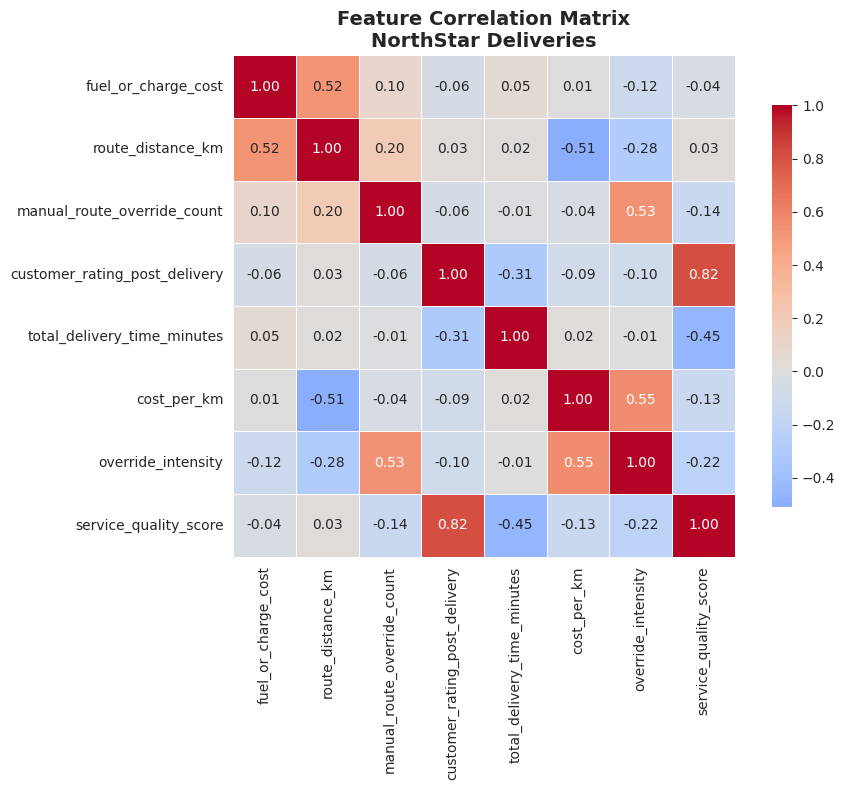

✓ Saved as 'chart_1_correlation_heatmap.png'



In [ ]:
# Chart 1: Correlation Heatmap

print("Chart 1: Correlation Matrix Heatmap\n")

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Feature Correlation Matrix\nNorthStar Deliveries', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/DBA/Python_Graphs/chart_1_correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Saved as 'chart_1_correlation_heatmap.png'\n")

Chart 2: Service Quality Score Distribution



/tmp/ipykernel_7502/3581977198.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=deliveries, x='delivery_status', y='service_quality_score',
/tmp/ipykernel_7502/3581977198.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=deliveries, x='delivery_status', y='service_quality_score',


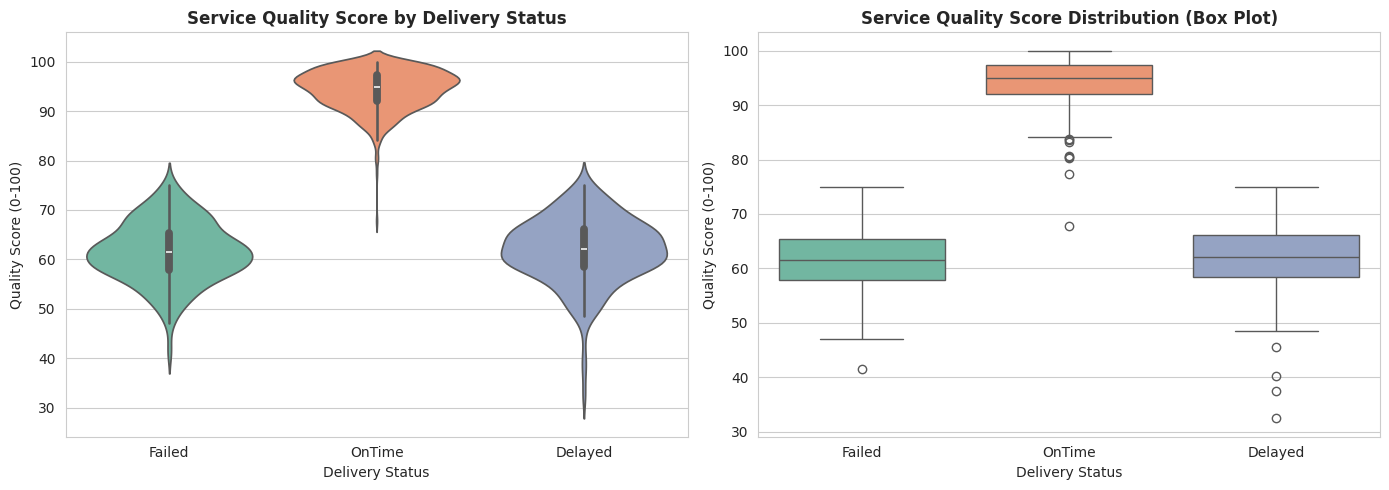

✓ Saved as 'chart_2_quality_score_distribution.png'



In [ ]:
# Chart 2: Service Quality Score Distribution by Delivery Status

print("Chart 2: Service Quality Score Distribution\n")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Violin plot by delivery status
sns.violinplot(data=deliveries, x='delivery_status', y='service_quality_score',
               palette='Set2', ax=axes[0])
axes[0].set_title('Service Quality Score by Delivery Status', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Quality Score (0-100)')
axes[0].set_xlabel('Delivery Status')

# Box plot showing outliers more clearly
sns.boxplot(data=deliveries, x='delivery_status', y='service_quality_score',
            palette='Set2', ax=axes[1])
axes[1].set_title('Service Quality Score Distribution (Box Plot)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Quality Score (0-100)')
axes[1].set_xlabel('Delivery Status')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/DBA/Python_Graphs/chart_2_quality_score_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Saved as 'chart_2_quality_score_distribution.png'\n")

Chart 3: Cost Efficiency vs Customer Rating



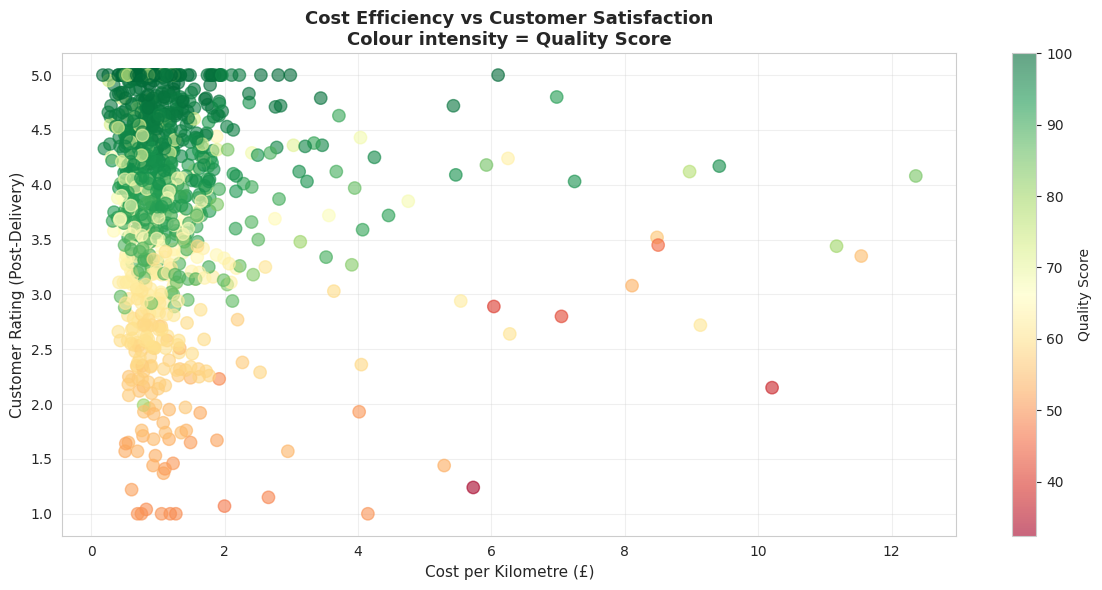

✓ Saved as 'chart_3_cost_efficiency_scatter.png'



In [ ]:
# Chart 3: Cost Efficiency Analysis (Scatter)

print("Chart 3: Cost Efficiency vs Customer Rating\n")

plt.figure(figsize=(12, 6))

# Create scatter plot
scatter = plt.scatter(deliveries['cost_per_km'],
                     deliveries['customer_rating_post_delivery'],
                     c=deliveries['service_quality_score'],
                     s=80, alpha=0.6, cmap='RdYlGn')

plt.xlabel('Cost per Kilometre (£)', fontsize=11)
plt.ylabel('Customer Rating (Post-Delivery)', fontsize=11)
plt.title('Cost Efficiency vs Customer Satisfaction\nColour intensity = Quality Score',
          fontsize=13, fontweight='bold')

cbar = plt.colorbar(scatter, label='Quality Score')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/DBA/Python_Graphs/chart_3_cost_efficiency_scatter.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Saved as 'chart_3_cost_efficiency_scatter.png'\n")

Chart 4: Route Override Intensity by Hub



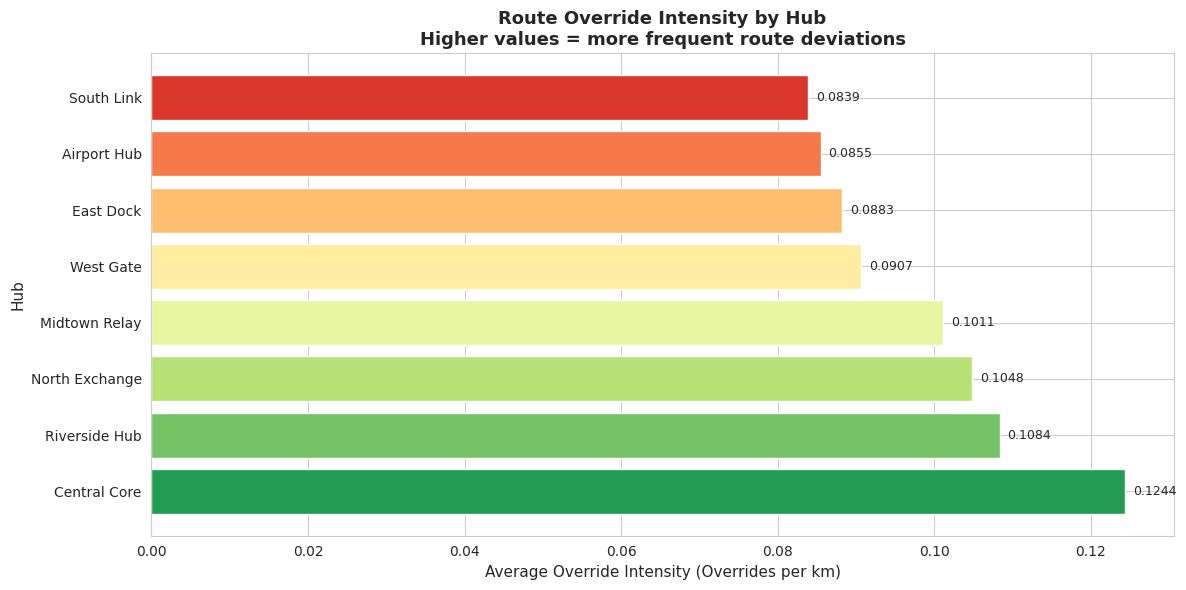

✓ Saved as 'chart_4_override_intensity_hub.png'



In [ ]:
# Chart 4: Override Intensity by Hub

print("Chart 4: Route Override Intensity by Hub\n")

hub_names = hubs.set_index('hub_id')['hub_name'].to_dict()

override_by_hub = deliveries.groupby('hub_id').agg({
    'override_intensity': 'mean',
    'delivery_id': 'count'
}).sort_values('override_intensity', ascending=False)

override_by_hub['hub_name'] = override_by_hub.index.map(hub_names)

plt.figure(figsize=(12, 6))

bars = plt.barh(override_by_hub['hub_name'],
               override_by_hub['override_intensity'],
               color=sns.color_palette('RdYlGn_r', len(override_by_hub)))

plt.xlabel('Average Override Intensity (Overrides per km)', fontsize=11)
plt.ylabel('Hub', fontsize=11)
plt.title('Route Override Intensity by Hub\nHigher values = more frequent route deviations',
          fontsize=13, fontweight='bold')

# Add value labels on bars
for idx, (hub, val) in enumerate(zip(override_by_hub['hub_name'],
                                     override_by_hub['override_intensity'])):
    plt.text(val + 0.001, idx, f'{val:.4f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/DBA/Python_Graphs/chart_4_override_intensity_hub.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Saved as 'chart_4_override_intensity_hub.png'\n")


Chart 5: Service Type Profitability Analysis



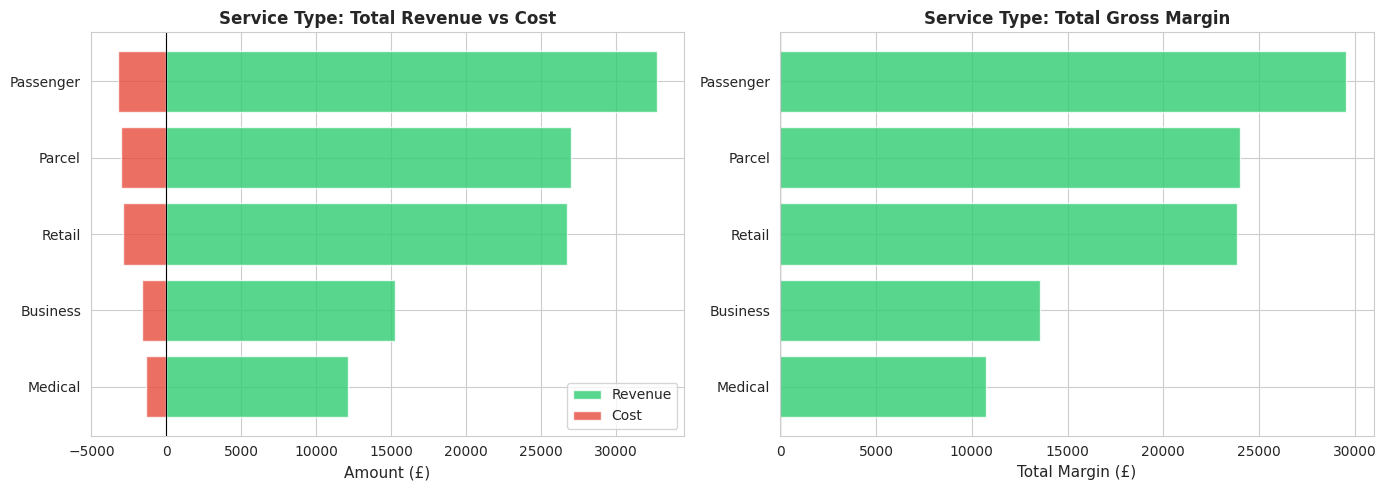

✓ Saved as 'chart_5_service_profitability.png'



In [ ]:
# Chart 5: Service Type Revenue vs Margin

print("Chart 5: Service Type Profitability Analysis\n")

service_profit = orders.merge(deliveries[['order_id', 'fuel_or_charge_cost']],
                              on='order_id', how='left').groupby('service_type').agg({
    'order_value': ['sum', 'mean'],
    'fuel_or_charge_cost': 'sum'
})

service_profit.columns = ['total_revenue', 'avg_value', 'total_cost']
service_profit['total_margin'] = service_profit['total_revenue'] - service_profit['total_cost']
service_profit = service_profit.sort_values('total_margin', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Stacked bar chart
axes[0].barh(service_profit.index, service_profit['total_revenue'],
            label='Revenue', color='#2ecc71', alpha=0.8)
axes[0].barh(service_profit.index, -service_profit['total_cost'],
            label='Cost', color='#e74c3c', alpha=0.8)
axes[0].set_xlabel('Amount (£)', fontsize=11)
axes[0].set_title('Service Type: Total Revenue vs Cost', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].axvline(x=0, color='black', linewidth=0.8)

# Margin bar chart
colours = ['#c0392b' if x < 0 else '#2ecc71'
          for x in service_profit['total_margin']]
axes[1].barh(service_profit.index, service_profit['total_margin'], color=colours, alpha=0.8)
axes[1].set_xlabel('Total Margin (£)', fontsize=11)
axes[1].set_title('Service Type: Total Gross Margin', fontsize=12, fontweight='bold')
axes[1].axvline(x=0, color='black', linewidth=0.8)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/DBA/Python_Graphs/chart_5_service_profitability.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Saved as 'chart_5_service_profitability.png'\n")

Chart 6: High-Risk vs Low-Risk Customer Profiles



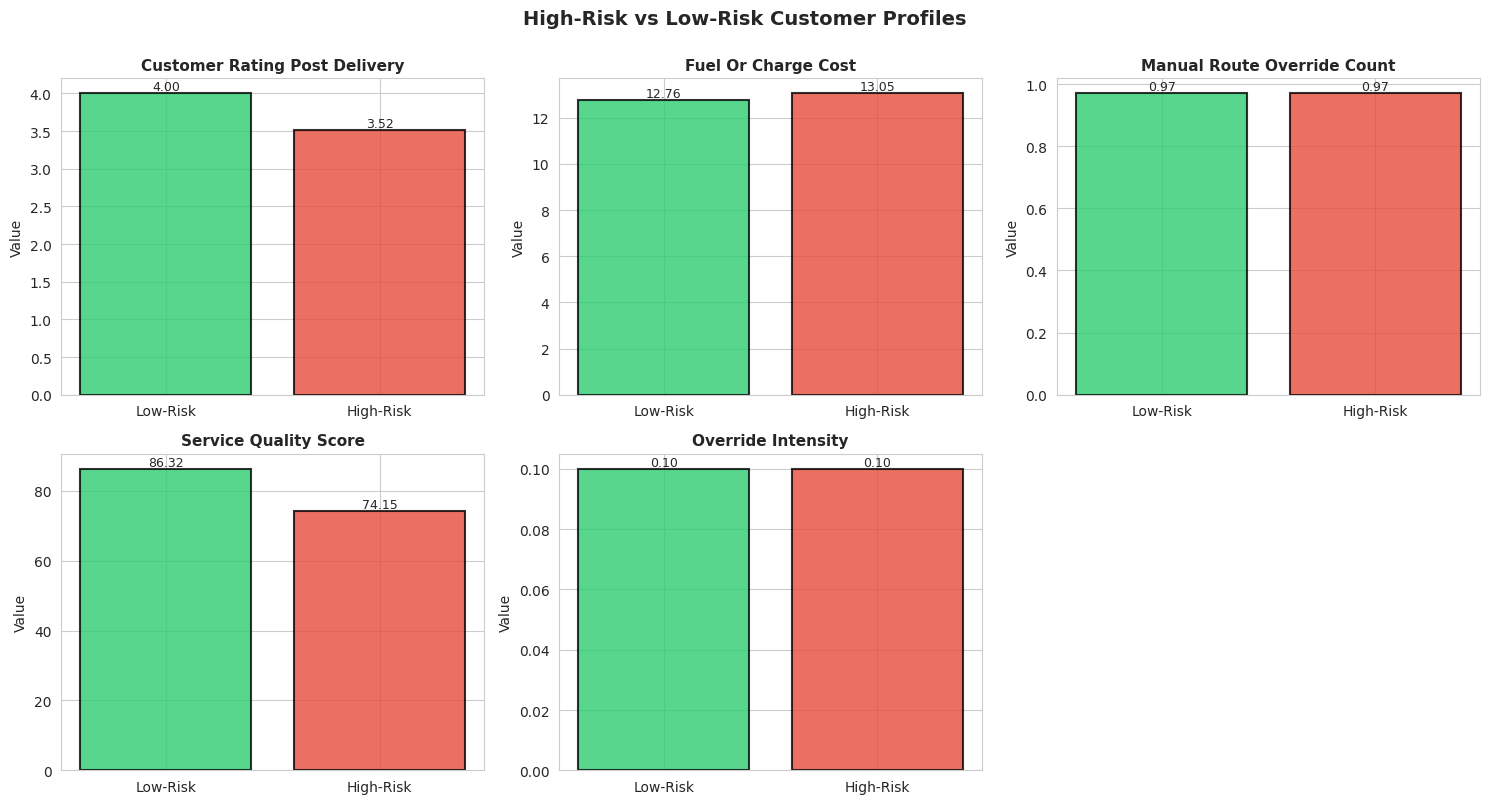

✓ Saved as 'chart_6_risk_profiles.png'



In [ ]:
# Chart 6: High-Risk Customer Characteristics

print("Chart 6: High-Risk vs Low-Risk Customer Profiles\n")

# Compare characteristics
risk_comparison = deliveries.groupby('is_high_risk').agg({
    'customer_rating_post_delivery': 'mean',
    'fuel_or_charge_cost': 'mean',
    'manual_route_override_count': 'mean',
    'service_quality_score': 'mean',
    'override_intensity': 'mean'
}).round(2)

risk_comparison.index = ['Low-Risk', 'High-Risk']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

metrics = risk_comparison.columns
colours_risk = ['#2ecc71', '#e74c3c']

for idx, metric in enumerate(metrics):
    bars = axes[idx].bar(risk_comparison.index, risk_comparison[metric],
                        color=colours_risk, alpha=0.8, edgecolor='black', linewidth=1.5)
    axes[idx].set_title(metric.replace('_', ' ').title(), fontsize=11, fontweight='bold')
    axes[idx].set_ylabel('Value')

    # Add value labels
    for bar in bars:
        height = bar.get_height()
        axes[idx].text(bar.get_x() + bar.get_width()/2., height,
                      f'{height:.2f}', ha='center', va='bottom', fontsize=9)

# Hide the 6th subplot (we only have 5 metrics)
axes[5].axis('off')

plt.suptitle('High-Risk vs Low-Risk Customer Profiles', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/DBA/Python_Graphs/chart_6_risk_profiles.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Saved as 'chart_6_risk_profiles.png'\n")


In [ ]:
# Save the cleaned tables to Clean_files to use in mongoDB uploading
deliveries.to_csv('/content/drive/MyDrive/DBA/Cleaned Files/deliveries_cleaned.csv', index=False)
orders.to_csv('/content/drive/MyDrive/DBA/Cleaned Files/orders_cleaned.csv', index=False)
hubs.to_csv('/content/drive/MyDrive/DBA/Cleaned Files/hubs_cleaned.csv', index=False)
drivers.to_csv('/content/drive/MyDrive/DBA/Cleaned Files/drivers_cleaned.csv', index=False)
app_events.to_csv('/content/drive/MyDrive/DBA/Cleaned Files/app_events_cleaned.csv', index=False)
complaints.to_csv('/content/drive/MyDrive/DBA/Cleaned Files/complaints_cleaned.csv', index=False)
customers.to_csv('/content/drive/MyDrive/DBA/Cleaned Files/customers_cleaned.csv', index=False)
incidents.to_csv('/content/drive/MyDrive/DBA/Cleaned Files/incidents_cleaned.csv', index=False)
vehicles.to_csv('/content/drive/MyDrive/DBA/Cleaned Files/vehicles_cleaned.csv', index=False)